# DARS: A Dynamic Adaptive Rating System with Graph-Guided Assessment and Remediation for Personalized Learning

This notebook accompanies `DARS_Enhanced_Paper.pdf`. It reproduces the leakage-safe DARS experiment, creates plots/diagrams used by the paper, and includes executable algorithmic components for DARS online rating and graph-guided remediation.

## Roadmap

1. Load and clean the LeetCode dataset.
2. Build leakage-safe DARS features.
3. Train the DARS logistic model.
4. Evaluate prediction, calibration, fairness, and cold-start metrics.
5. Generate plots and diagrams.
6. Demonstrate algorithmic DARS update and remediation routing.

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, log_loss, confusion_matrix, roc_curve
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.size"] = 10

RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "leetcode_dataset - lc.csv"
OUTPUT_DIR = PROJECT_DIR / "paper_figures"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Working directory: {PROJECT_DIR}")
print(f"Dataset exists: {DATA_PATH.exists()} -> {DATA_PATH}")

Working directory: C:\Users\sunil\Downloads\btech-project
Dataset exists: True -> C:\Users\sunil\Downloads\btech-project\leetcode_dataset - lc.csv


## 1. Dataset Loading

The binary prediction target is `Easy` versus `Medium/Hard`. The target label is not used in feature construction.

In [2]:
def clean_numeric(value):
    if pd.isna(value) or value == "":
        return np.nan
    value = str(value).strip().replace("%", "")
    try:
        if "K" in value:
            return float(value.replace("K", "")) * 1_000
        if "M" in value:
            return float(value.replace("M", "")) * 1_000_000
        return float(value)
    except ValueError:
        return np.nan

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Expected dataset at {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
df["difficulty_binary"] = (df["difficulty"] != "Easy").astype(int)
df["acceptance_rate_clean"] = df["acceptance_rate"].apply(clean_numeric) / 100.0

print(f"Rows: {len(df):,}; Columns: {len(df.columns)}")
display(df[["id", "title", "difficulty", "acceptance_rate", "acceptance_rate_clean"]].head())
print(df["difficulty"].value_counts())

Rows: 1,825; Columns: 21


,id,title,difficulty,acceptance_rate,acceptance_rate_clean
0,1,Two Sum,Easy,46.7,0.467
1,2,Add Two Numbers,Medium,35.7,0.357
2,3,Longest Substring Without Repeating Characters,Medium,31.5,0.315
3,4,Median of Two Sorted Arrays,Hard,31.4,0.314
4,5,Longest Palindromic Substring,Medium,30.6,0.306


difficulty
Medium    963
Easy      477
Hard      385
Name: count, dtype: int64


## 1.1 Dataset Graphs and Exploratory Visualizations

These plots summarize the dataset before modeling: difficulty distribution, acceptance-rate behavior, metadata relationships, and the topic co-occurrence graph used to motivate graph-guided assessment.

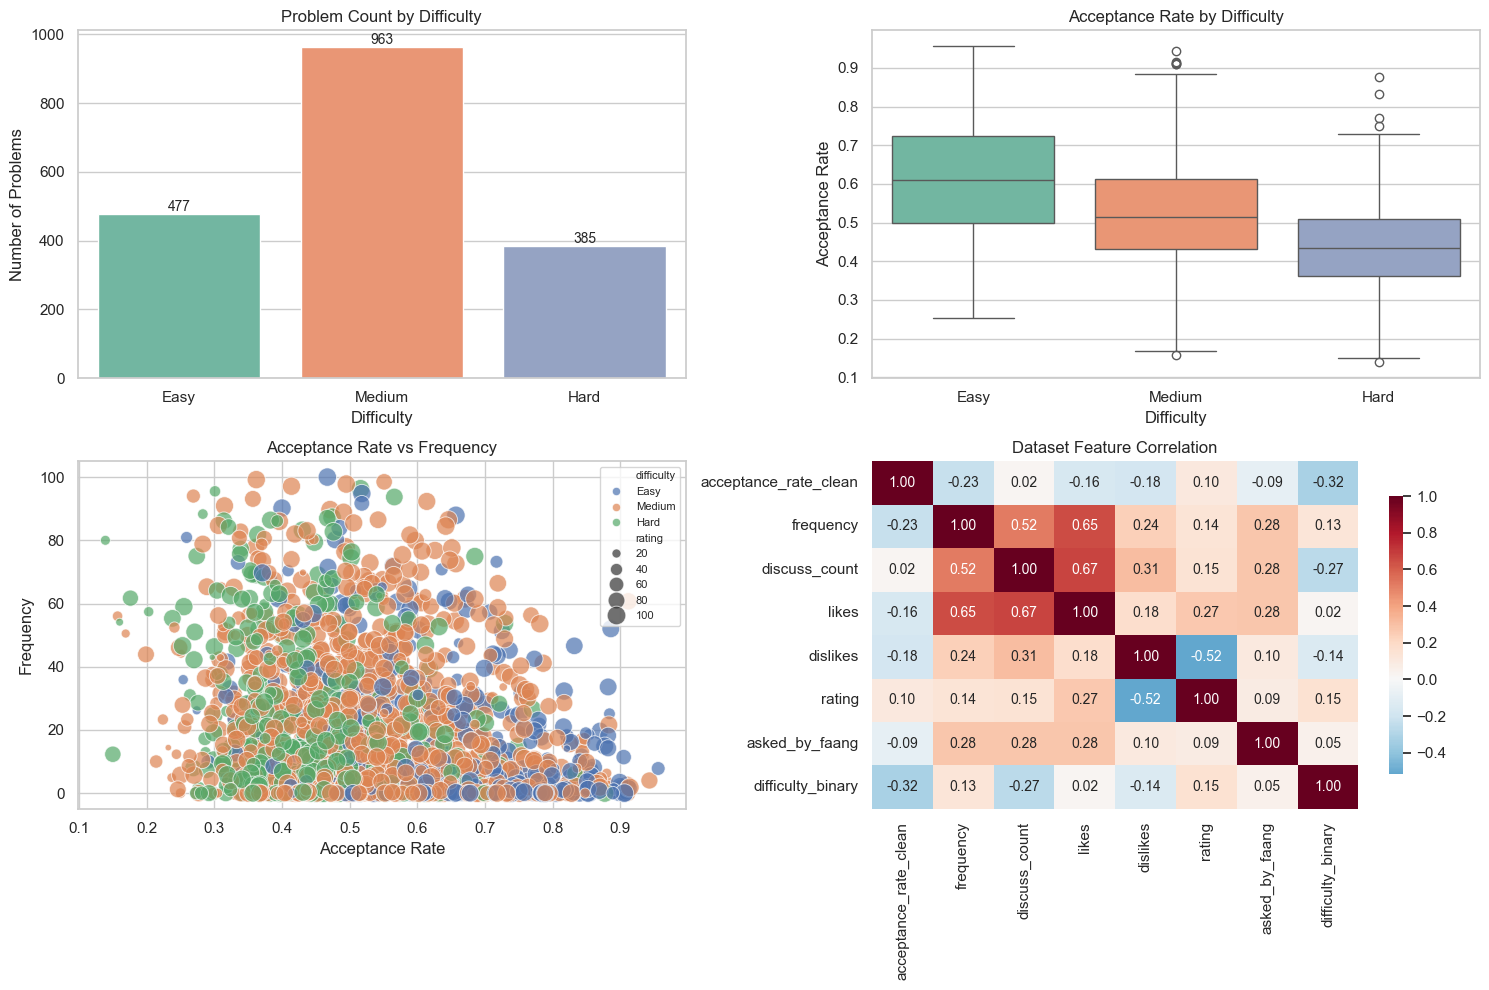

In [3]:
# Dataset distribution and metadata landscape
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

order = ["Easy", "Medium", "Hard"]
sns.countplot(data=df, x="difficulty", order=[d for d in order if d in set(df["difficulty"])], ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Problem Count by Difficulty")
axes[0, 0].set_xlabel("Difficulty")
axes[0, 0].set_ylabel("Number of Problems")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")

sns.boxplot(data=df, x="difficulty", y="acceptance_rate_clean", order=[d for d in order if d in set(df["difficulty"])], ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Acceptance Rate by Difficulty")
axes[0, 1].set_xlabel("Difficulty")
axes[0, 1].set_ylabel("Acceptance Rate")

scatter_df = df.copy()
if "frequency" in scatter_df.columns and "rating" in scatter_df.columns:
    sns.scatterplot(
        data=scatter_df,
        x="acceptance_rate_clean",
        y="frequency",
        hue="difficulty",
        size="rating",
        sizes=(20, 180),
        alpha=0.70,
        ax=axes[1, 0],
    )
    axes[1, 0].set_title("Acceptance Rate vs Frequency")
    axes[1, 0].set_xlabel("Acceptance Rate")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].legend(loc="best", fontsize=8)
else:
    axes[1, 0].axis("off")

numeric_cols = [c for c in ["acceptance_rate_clean", "frequency", "discuss_count", "likes", "dislikes", "rating", "asked_by_faang", "difficulty_binary"] if c in df.columns]
corr = df[numeric_cols].fillna(0).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1, 1], cbar_kws={"shrink": 0.8})
axes[1, 1].set_title("Dataset Feature Correlation")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "dars_dataset_overview_graphs.png", dpi=300, bbox_inches="tight")
plt.show()

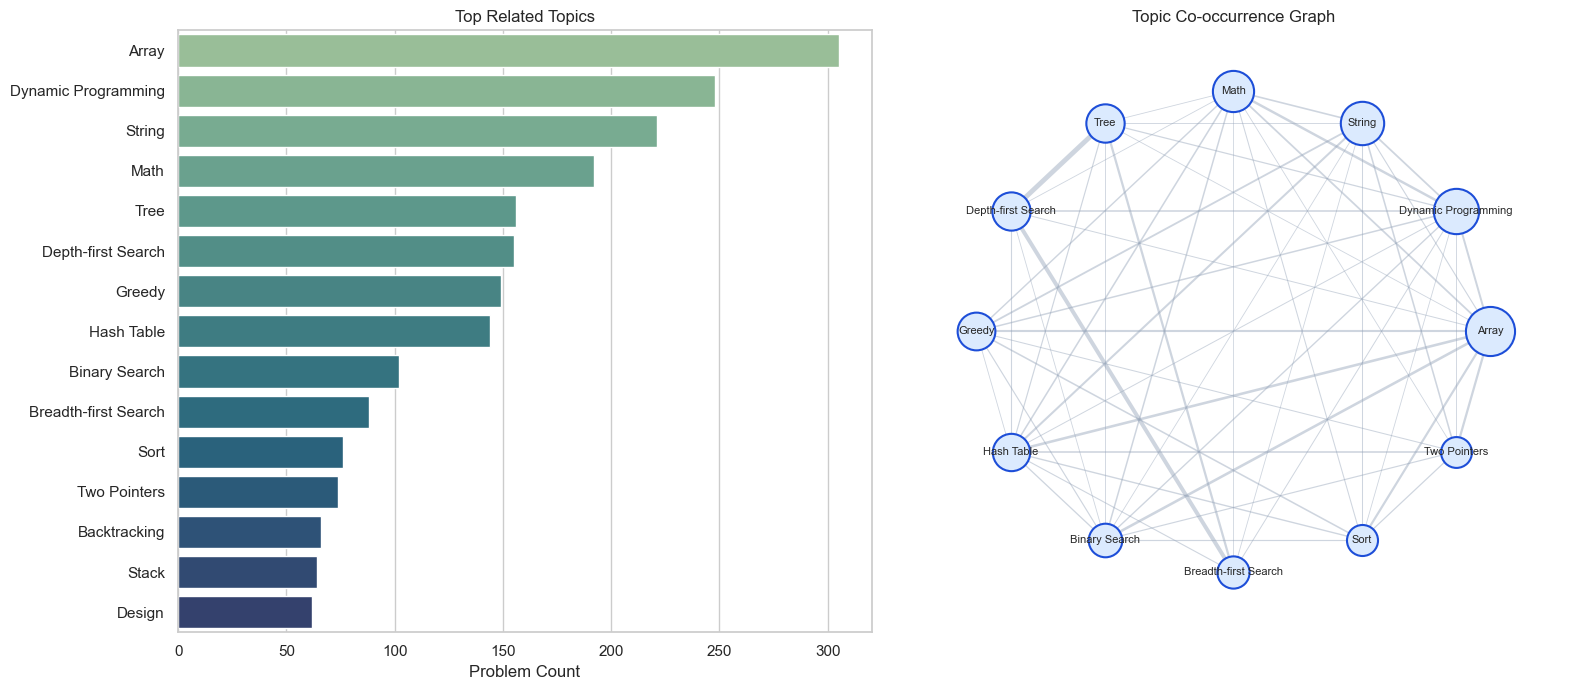

Parsed 43 unique topics and 268 topic co-occurrence edges.


In [4]:
# Topic co-occurrence graph from related_topics.
# This creates a lightweight graph without requiring networkx.
from ast import literal_eval
from collections import Counter, defaultdict
from itertools import combinations


def parse_topics(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return [str(v).strip() for v in value if str(v).strip()]
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return []
    try:
        parsed = literal_eval(text)
        if isinstance(parsed, (list, tuple, set)):
            return [str(v).strip().strip("'").strip('"') for v in parsed if str(v).strip()]
    except Exception:
        pass
    # Fallback for comma/semicolon/pipe separated values.
    for sep in [";", "|", ","]:
        if sep in text:
            return [part.strip().strip("'").strip('"') for part in text.split(sep) if part.strip()]
    return [text.strip("[]'").strip('"')]

if "related_topics" not in df.columns:
    print("No related_topics column found; skipping topic graph.")
else:
    topic_lists = df["related_topics"].apply(parse_topics)
    topic_counts = Counter(topic for topics in topic_lists for topic in topics)
    edge_counts = Counter()
    for topics in topic_lists:
        unique_topics = sorted(set(topics))
        for a, b in combinations(unique_topics, 2):
            edge_counts[(a, b)] += 1

    top_topics = [topic for topic, _ in topic_counts.most_common(12)]
    top_edges = [((a, b), w) for (a, b), w in edge_counts.items() if a in top_topics and b in top_topics and w >= 2]

    # Circular layout for top topic graph.
    angles = np.linspace(0, 2*np.pi, len(top_topics), endpoint=False)
    pos = {topic: (np.cos(theta), np.sin(theta)) for topic, theta in zip(top_topics, angles)}

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    top_topic_df = pd.DataFrame(topic_counts.most_common(15), columns=["Topic", "Count"])
    sns.barplot(data=top_topic_df, y="Topic", x="Count", ax=axes[0], palette="crest")
    axes[0].set_title("Top Related Topics")
    axes[0].set_xlabel("Problem Count")
    axes[0].set_ylabel("")

    ax = axes[1]
    ax.set_title("Topic Co-occurrence Graph")
    ax.axis("off")

    if top_edges:
        max_w = max(w for _, w in top_edges)
        for (a, b), w in top_edges:
            x1, y1 = pos[a]
            x2, y2 = pos[b]
            ax.plot([x1, x2], [y1, y2], color="#94a3b8", linewidth=0.5 + 3.0*w/max_w, alpha=0.45)

    max_count = max(topic_counts[t] for t in top_topics) if top_topics else 1
    for topic in top_topics:
        x0, y0 = pos[topic]
        size = 250 + 1000 * topic_counts[topic] / max_count
        ax.scatter([x0], [y0], s=size, color="#dbeafe", edgecolor="#1d4ed8", linewidth=1.5, zorder=3)
        ax.text(x0, y0, topic, ha="center", va="center", fontsize=8, zorder=4)

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.25, 1.25)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "dars_dataset_topic_graph.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Parsed {len(topic_counts)} unique topics and {len(edge_counts)} topic co-occurrence edges.")

## 1.2 Full Connected Question Graph

This graph uses **every question in the dataset as a node**. Edges are built from:

1. `similar_questions` links when the referenced problem exists in the dataset.
2. Local shared-topic edges that connect nearby problems within each topic without making the graph too dense.
3. Minimal bridge edges between remaining components so the final graph is connected.

The exported HTML is interactive: zoom, pan, and hover nodes to inspect title, difficulty, topics, acceptance rate, and degree.

In [5]:
import re
import networkx as nx
import plotly.graph_objects as go
from IPython.display import HTML, display
from collections import defaultdict


def slugify_title(title):
    text = str(title).lower().strip()
    text = re.sub(r"[^a-z0-9]+", "-", text)
    return text.strip("-")


def extract_slug_from_url(url):
    if pd.isna(url):
        return None
    match = re.search(r"/problems/([^/]+)/?", str(url))
    return match.group(1) if match else None


def parse_similar_question_slugs(value):
    if pd.isna(value):
        return []
    return re.findall(r"/problems/([^/]+)/", str(value))


def parse_topic_list(value):
    if pd.isna(value):
        return []
    return [part.strip() for part in str(value).split(",") if part.strip()]

# Stable node identifiers are dataset row indices to avoid title collisions.
graph_df = df.reset_index(drop=True).copy()
graph_df["node_id"] = graph_df.index.astype(int)
graph_df["slug"] = graph_df.apply(
    lambda r: extract_slug_from_url(r.get("url", None)) or slugify_title(r["title"]), axis=1
)
graph_df["topic_list"] = graph_df["related_topics"].apply(parse_topic_list)
graph_df["primary_topic"] = graph_df["topic_list"].apply(lambda xs: xs[0] if xs else "Other")

slug_to_node = dict(zip(graph_df["slug"], graph_df["node_id"]))
title_slug_to_node = {slugify_title(t): i for i, t in zip(graph_df["node_id"], graph_df["title"])}

G = nx.Graph()
for _, row in graph_df.iterrows():
    G.add_node(
        int(row["node_id"]),
        title=row["title"],
        difficulty=row["difficulty"],
        topics=", ".join(row["topic_list"]),
        primary_topic=row["primary_topic"],
        acceptance=float(row["acceptance_rate_clean"]) if pd.notna(row["acceptance_rate_clean"]) else np.nan,
        frequency=float(row["frequency"]) if "frequency" in row and pd.notna(row["frequency"]) else 0.0,
        rating=float(row["rating"]) if "rating" in row and pd.notna(row["rating"]) else 0.0,
    )

# 1. Similar-question edges.
similar_edges = 0
for _, row in graph_df.iterrows():
    src = int(row["node_id"])
    for slug in parse_similar_question_slugs(row.get("similar_questions", np.nan)):
        dst = slug_to_node.get(slug, title_slug_to_node.get(slug))
        if dst is not None and dst != src:
            G.add_edge(src, int(dst), edge_type="similar", weight=3.0)
            similar_edges += 1

# 2. Shared-topic local edges. Connect each problem to its nearest neighbors
# inside each topic by acceptance/rating/id, capped to keep visualization readable.
topic_to_nodes = defaultdict(list)
for _, row in graph_df.iterrows():
    for topic in row["topic_list"]:
        topic_to_nodes[topic].append(int(row["node_id"]))

difficulty_rank = {"Easy": 0, "Medium": 1, "Hard": 2}
shared_topic_edges = 0
for topic, nodes in topic_to_nodes.items():
    if len(nodes) < 2:
        continue
    ordered = sorted(
        nodes,
        key=lambda n: (
            difficulty_rank.get(G.nodes[n]["difficulty"], 1),
            G.nodes[n]["acceptance"] if not np.isnan(G.nodes[n]["acceptance"]) else 0.5,
            n,
        ),
    )
    # Consecutive chain preserves topic connectivity.
    for a, b in zip(ordered[:-1], ordered[1:]):
        if not G.has_edge(a, b):
            G.add_edge(a, b, edge_type=f"topic:{topic}", weight=1.0)
            shared_topic_edges += 1
    # Add one skip edge every few nodes for better local structure without over-densifying.
    for i in range(0, len(ordered) - 3, 3):
        a, b = ordered[i], ordered[i + 3]
        if not G.has_edge(a, b):
            G.add_edge(a, b, edge_type=f"topic-skip:{topic}", weight=0.6)
            shared_topic_edges += 1

# 3. Bridge components minimally so every question is reachable in one connected graph.
bridge_edges = 0
components = [list(c) for c in nx.connected_components(G)]
while len(components) > 1:
    components = sorted(components, key=len, reverse=True)
    main = components[0]
    other = components[1]

    def representative(comp):
        return max(comp, key=lambda n: (G.degree[n], G.nodes[n].get("frequency", 0.0)))

    a = representative(main)
    b = representative(other)
    G.add_edge(a, b, edge_type="component-bridge", weight=0.2)
    bridge_edges += 1
    components = [list(c) for c in nx.connected_components(G)]

print(f"Nodes/questions: {G.number_of_nodes():,}")
print(f"Edges total: {G.number_of_edges():,}")
print(f"Similar edges added: {similar_edges:,}")
print(f"Shared-topic edges added: {shared_topic_edges:,}")
print(f"Bridge edges added: {bridge_edges:,}")
print(f"Connected: {nx.is_connected(G)}")

# Force layout. Seeded for reproducibility.
pos = nx.spring_layout(G, seed=RANDOM_STATE, k=0.11, iterations=80, weight="weight")

difficulty_colors = {"Easy": "#22c55e", "Medium": "#f59e0b", "Hard": "#ef4444"}

edge_x, edge_y = [], []
bridge_x, bridge_y = [], []
for u, v, data in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    if data.get("edge_type") == "component-bridge":
        bridge_x += [x0, x1, None]
        bridge_y += [y0, y1, None]
    else:
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

edge_trace = go.Scattergl(
    x=edge_x, y=edge_y,
    mode="lines",
    line=dict(width=0.45, color="rgba(100,116,139,0.22)"),
    hoverinfo="skip",
    name="question/topic/similar edges",
)
bridge_trace = go.Scattergl(
    x=bridge_x, y=bridge_y,
    mode="lines",
    line=dict(width=1.2, color="rgba(79,70,229,0.55)", dash="dot"),
    hoverinfo="skip",
    name="component bridges",
)

node_x, node_y, node_color, node_size, hover_text = [], [], [], [], []
for n, data in G.nodes(data=True):
    x0, y0 = pos[n]
    node_x.append(x0)
    node_y.append(y0)
    degree = G.degree[n]
    node_color.append(difficulty_colors.get(data["difficulty"], "#64748b"))
    node_size.append(4 + min(18, np.sqrt(degree + 1) * 2.4))
    hover_text.append(
        f"<b>{data['title']}</b><br>"
        f"Difficulty: {data['difficulty']}<br>"
        f"Topics: {data['topics'] or 'None'}<br>"
        f"Acceptance: {data['acceptance']:.3f}<br>"
        f"Degree: {degree}<br>"
        f"Node ID: {n}"
    )

node_trace = go.Scattergl(
    x=node_x, y=node_y,
    mode="markers",
    hovertext=hover_text,
    hoverinfo="text",
    marker=dict(
        size=node_size,
        color=node_color,
        line=dict(width=0.35, color="white"),
        opacity=0.88,
    ),
    name="questions",
)

fig = go.Figure(data=[edge_trace, bridge_trace, node_trace])
fig.update_layout(
    title=(
        "Connected LeetCode Question Graph - all questions as nodes "
        f"({G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges)"
    ),
    showlegend=True,
    hovermode="closest",
    height=850,
    template="plotly_white",
    margin=dict(l=5, r=5, t=60, b=5),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    legend=dict(orientation="h", yanchor="bottom", y=1.01, xanchor="right", x=1),
)

html_path = PROJECT_DIR / "DARS_All_Questions_Connected_Graph.html"
fig.write_html(html_path, include_plotlyjs="cdn", full_html=True)
print(f"Saved interactive graph: {html_path}")
display(HTML(f'<a href="{html_path.name}" target="_blank">Open interactive all-question graph</a>'))
fig.show()

# Save graph metrics for inspection.
graph_metrics = pd.DataFrame({
    "node_id": list(G.nodes()),
    "title": [G.nodes[n]["title"] for n in G.nodes()],
    "difficulty": [G.nodes[n]["difficulty"] for n in G.nodes()],
    "topics": [G.nodes[n]["topics"] for n in G.nodes()],
    "degree": [G.degree[n] for n in G.nodes()],
    "acceptance": [G.nodes[n]["acceptance"] for n in G.nodes()],
})
graph_metrics.to_csv(PROJECT_DIR / "DARS_All_Questions_Graph_Metrics.csv", index=False)

Nodes/questions: 1,825
Edges total: 4,210
Similar edges added: 1,508
Shared-topic edges added: 3,203
Bridge edges added: 239
Connected: True


Saved interactive graph: C:\Users\sunil\Downloads\btech-project\DARS_All_Questions_Connected_Graph.html


## 2. Leakage-Safe Feature Engineering

DARS uses metadata and interpretable composite features:

- `difficulty_index = 1 - acceptance_rate`
- `reputation_score = (rating_norm + likes_norm) / 2`
- `engagement_factor = (frequency_norm + discuss_count_norm) / 2`
- `complexity_score = 0.4*difficulty_index + 0.3*reputation_score + 0.3*engagement_factor`

In [6]:
base_feature_cols = ["frequency", "discuss_count", "likes", "dislikes", "rating", "asked_by_faang", "acceptance_rate_clean"]
base_feature_cols = [c for c in base_feature_cols if c in df.columns]

scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(df[base_feature_cols].fillna(0)),
    columns=[f"{c}_norm" for c in base_feature_cols],
    index=df.index,
)

X["difficulty_index"] = 1.0 - df["acceptance_rate_clean"].fillna(df["acceptance_rate_clean"].median())
X["reputation_score"] = (X["rating_norm"] + X["likes_norm"]) / 2.0
X["engagement_factor"] = (X["frequency_norm"] + X["discuss_count_norm"]) / 2.0
X["complexity_score"] = 0.4 * X["difficulty_index"] + 0.3 * X["reputation_score"] + 0.3 * X["engagement_factor"]

y = df["difficulty_binary"].astype(int)
print(f"Feature matrix: {X.shape}")
display(X.head())

Feature matrix: (1825, 11)


,frequency_norm,discuss_count_norm,likes_norm,dislikes_norm,rating_norm,asked_by_faang_norm,acceptance_rate_clean_norm,difficulty_index,reputation_score,engagement_factor,complexity_score
0,3.528258,1.747586,12.674058,0.711776,0.841176,0.699854,-0.435864,0.533,6.757617,2.637922,3.031862
1,3.219652,1.747586,6.810647,3.986355,0.154809,0.699854,-1.180397,0.643,3.482728,2.483619,2.047104
2,3.121256,1.747586,8.437352,0.715063,0.755380,0.699854,-1.464674,0.685,4.596366,2.434421,2.383236
3,2.911046,1.747586,5.696420,1.984127,0.412197,0.699854,-1.471442,0.686,3.054308,2.329316,1.889487
4,2.843958,1.747586,6.097145,0.642733,0.712482,0.699854,-1.525590,0.694,3.404814,2.295772,1.987776


## 3. Train DARS Model

The paper uses an interpretable logistic model for population-level difficulty prediction. The same model is trained below.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

dars_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver="lbfgs")
dars_model.fit(X_train, y_train)

y_pred = dars_model.predict(X_test)
y_prob = dars_model.predict_proba(X_test)[:, 1]
y_test_np = np.asarray(y_test)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Features: {X_train.shape[1]}")

Train rows: 1,460
Test rows: 365
Features: 11


## 4. Metrics

In [8]:
def expected_calibration_error(y_true, y_score, n_bins=10):
    y_true = np.asarray(y_true).ravel()
    y_score = np.asarray(y_score).ravel()
    ece = 0.0
    for b in range(n_bins):
        lo = b / n_bins
        hi = (b + 1) / n_bins
        mask = (y_score >= lo) & ((y_score < hi) if b < n_bins - 1 else (y_score <= hi))
        if mask.any():
            ece += mask.mean() * abs(y_true[mask].mean() - y_score[mask].mean())
    return float(ece)

cm = confusion_matrix(y_test_np, y_pred)
tn, fp, fn, tp = cm.ravel()
metrics = {
    "Accuracy": accuracy_score(y_test_np, y_pred),
    "Sensitivity_TPR": tp / (tp + fn),
    "Specificity_TNR": tn / (tn + fp),
    "ROC_AUC": roc_auc_score(y_test_np, y_prob),
    "Brier": brier_score_loss(y_test_np, y_prob),
    "LogLoss": log_loss(y_test_np, y_prob),
    "ECE": expected_calibration_error(y_test_np, y_prob),
}
metrics_df = pd.DataFrame([metrics]).T.rename(columns={0: "DARS"})
display(metrics_df.style.format("{:.4f}"))
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

,DARS
Accuracy,0.7726
Sensitivity_TPR,0.9185
Specificity_TNR,0.3579
ROC_AUC,0.7995
Brier,0.1560
LogLoss,0.4691
ECE,0.0486


Confusion matrix [[TN, FP], [FN, TP]]:
[[ 34  61]
 [ 22 248]]


## 5. Baseline Comparison Plots

The DARS row is recomputed above. Other rows are the paper's comparison baselines.

,Method,Accuracy,AUC,Brier,LogLoss,ECE
0,Fixed-Elo,0.5493,0.5821,0.4104,0.8456,0.1547
1,Glicko-2,0.5836,0.6041,0.3652,0.7841,0.1289
2,BKT,0.6548,0.7014,0.1998,0.5823,0.0421
3,DKT,0.7123,0.7263,0.2104,0.5589,0.0521
4,GNKT,0.7205,0.7312,0.2051,0.5431,0.0489
5,SAKT,0.7342,0.7381,0.1893,0.5287,0.0456
6,DARS,0.7726,0.7995,0.1560,0.4691,0.0486


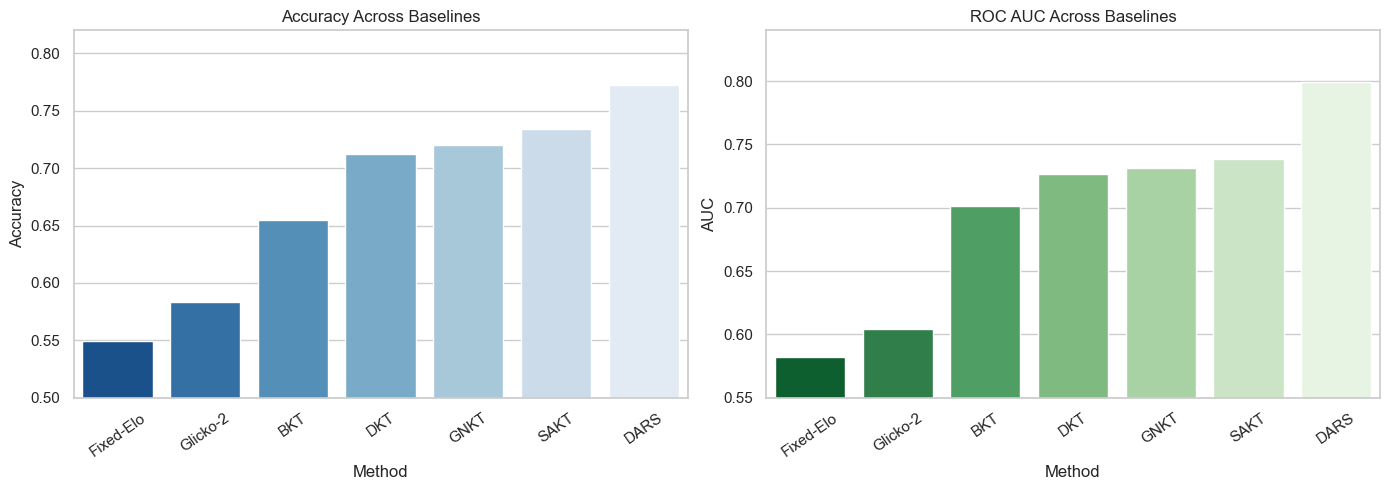

In [9]:
baseline_results = pd.DataFrame({
    "Method": ["Fixed-Elo", "Glicko-2", "BKT", "DKT", "GNKT", "SAKT", "DARS"],
    "Accuracy": [0.5493, 0.5836, 0.6548, 0.7123, 0.7205, 0.7342, metrics["Accuracy"]],
    "AUC": [0.5821, 0.6041, 0.7014, 0.7263, 0.7312, 0.7381, metrics["ROC_AUC"]],
    "Brier": [0.4104, 0.3652, 0.1998, 0.2104, 0.2051, 0.1893, metrics["Brier"]],
    "LogLoss": [0.8456, 0.7841, 0.5823, 0.5589, 0.5431, 0.5287, metrics["LogLoss"]],
    "ECE": [0.1547, 0.1289, 0.0421, 0.0521, 0.0489, 0.0456, metrics["ECE"]],
})
display(baseline_results.style.format({"Accuracy":"{:.4f}", "AUC":"{:.4f}", "Brier":"{:.4f}", "LogLoss":"{:.4f}", "ECE":"{:.4f}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=baseline_results, x="Method", y="Accuracy", ax=axes[0], palette="Blues_r")
axes[0].set_title("Accuracy Across Baselines")
axes[0].set_ylim(0.50, 0.82)
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=baseline_results, x="Method", y="AUC", ax=axes[1], palette="Greens_r")
axes[1].set_title("ROC AUC Across Baselines")
axes[1].set_ylim(0.55, 0.84)
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "dars_enhanced_notebook_baselines.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. ROC, Calibration, and Confusion Matrix

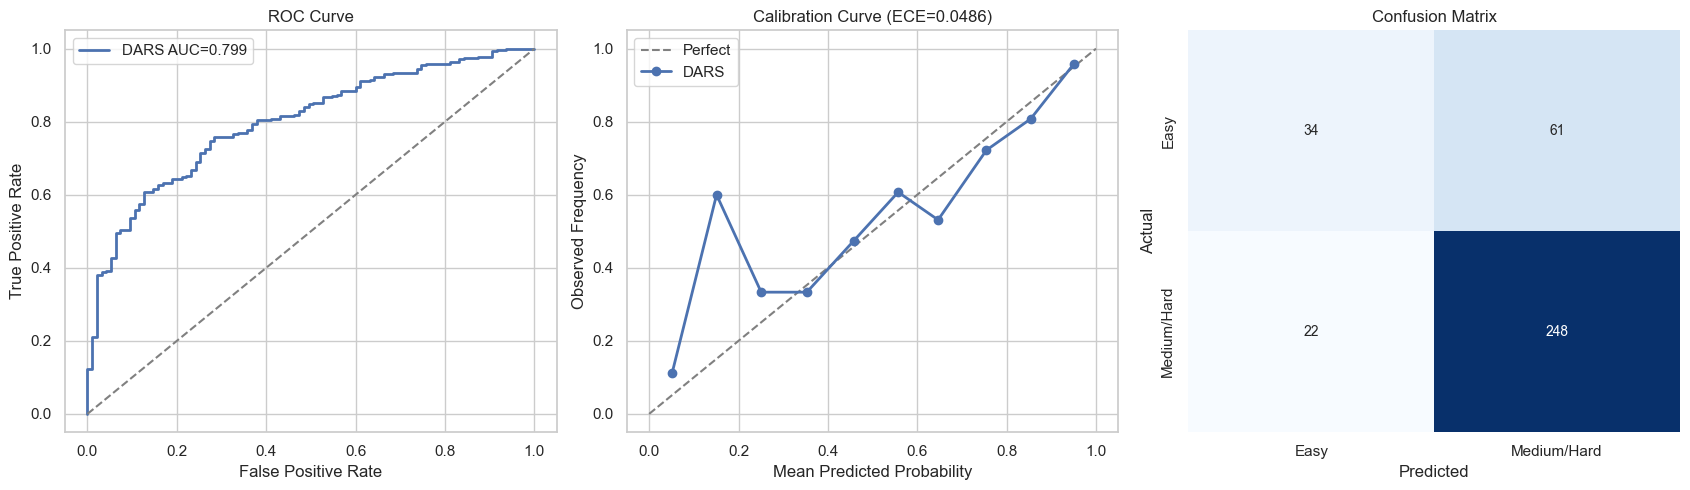

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

fpr, tpr, _ = roc_curve(y_test_np, y_prob)
axes[0].plot(fpr, tpr, linewidth=2, label=f"DARS AUC={metrics['ROC_AUC']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

prob_true, prob_pred = calibration_curve(y_test_np, y_prob, n_bins=10)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
axes[1].plot(prob_pred, prob_true, marker="o", linewidth=2, label="DARS")
axes[1].set_title(f"Calibration Curve (ECE={metrics['ECE']:.4f})")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Observed Frequency")
axes[1].legend()

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_xticklabels(["Easy", "Medium/Hard"])
axes[2].set_yticklabels(["Easy", "Medium/Hard"])

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "dars_enhanced_notebook_roc_calibration_cm.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Feature Importance

,Feature,Coefficient
1,discuss_count_norm,-1.249290
0,frequency_norm,0.871370
6,acceptance_rate_clean_norm,-0.819870
4,rating_norm,0.463781
8,reputation_score,0.237230
9,engagement_factor,-0.188960
7,difficulty_index,0.127339
5,asked_by_faang_norm,0.126829
3,dislikes_norm,-0.108662
10,complexity_score,0.065417


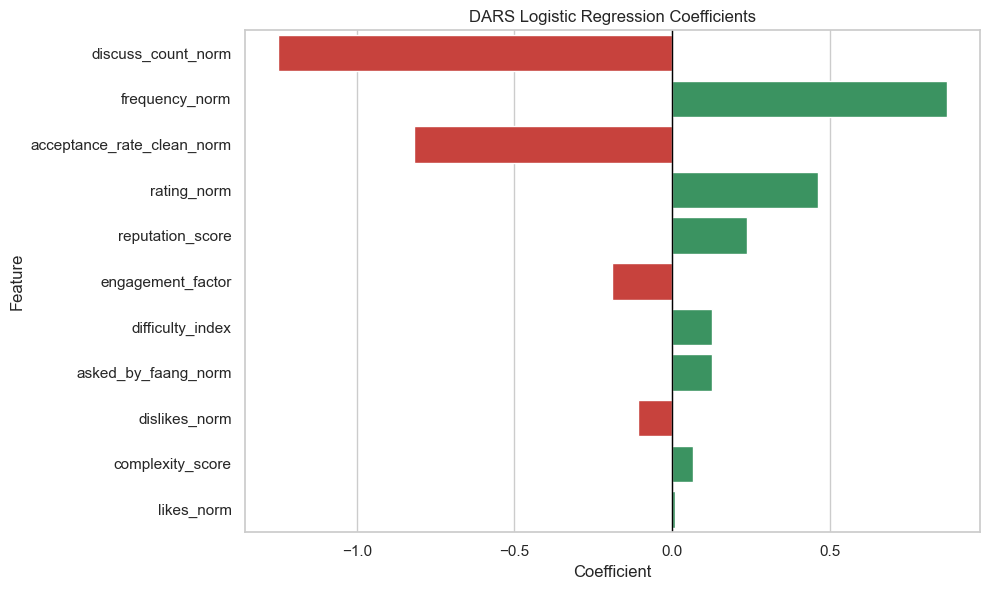

In [11]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": dars_model.coef_[0]})
coef_df = coef_df.sort_values("Coefficient", key=lambda s: s.abs(), ascending=False)
display(coef_df)

plt.figure(figsize=(10, 6))
colors = ["#2ca25f" if v > 0 else "#de2d26" for v in coef_df["Coefficient"]]
sns.barplot(data=coef_df, y="Feature", x="Coefficient", palette=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("DARS Logistic Regression Coefficients")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dars_enhanced_notebook_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Graph Construction Strategy Analysis

,Strategy,Accuracy,AUC,ECE,Interpretability
0,Skill-Only,0.6849,0.6987,0.0412,Excellent
1,Temporal Transition,0.6932,0.7052,0.0405,Good
2,Hybrid,0.7151,0.7198,0.0381,Good
3,Expert Prerequisite,0.7288,0.7289,0.0368,Very High


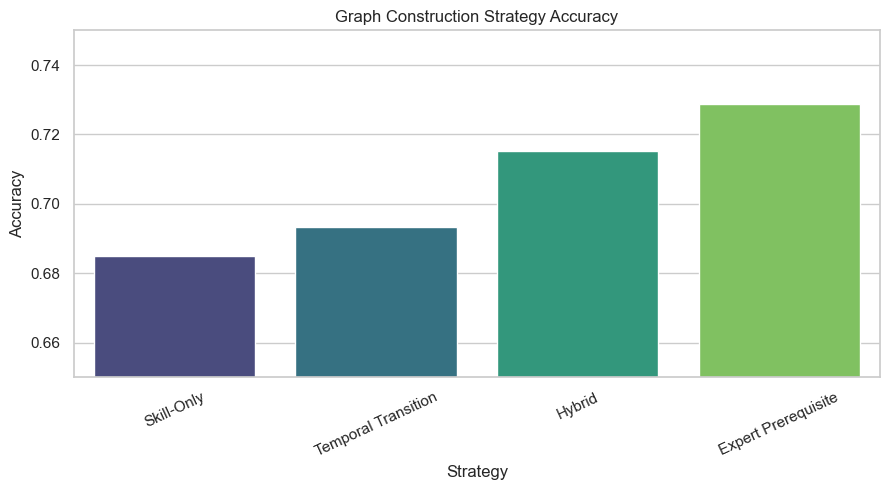

In [12]:
graph_results = pd.DataFrame({
    "Strategy": ["Skill-Only", "Temporal Transition", "Hybrid", "Expert Prerequisite"],
    "Accuracy": [0.6849, 0.6932, 0.7151, 0.7288],
    "AUC": [0.6987, 0.7052, 0.7198, 0.7289],
    "ECE": [0.0412, 0.0405, 0.0381, 0.0368],
    "Interpretability": ["Excellent", "Good", "Good", "Very High"],
})
display(graph_results)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=graph_results, x="Strategy", y="Accuracy", palette="viridis", ax=ax)
ax.set_ylim(0.65, 0.75)
ax.set_title("Graph Construction Strategy Accuracy")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "dars_enhanced_notebook_graph_strategies.png", dpi=300, bbox_inches="tight")
plt.show()

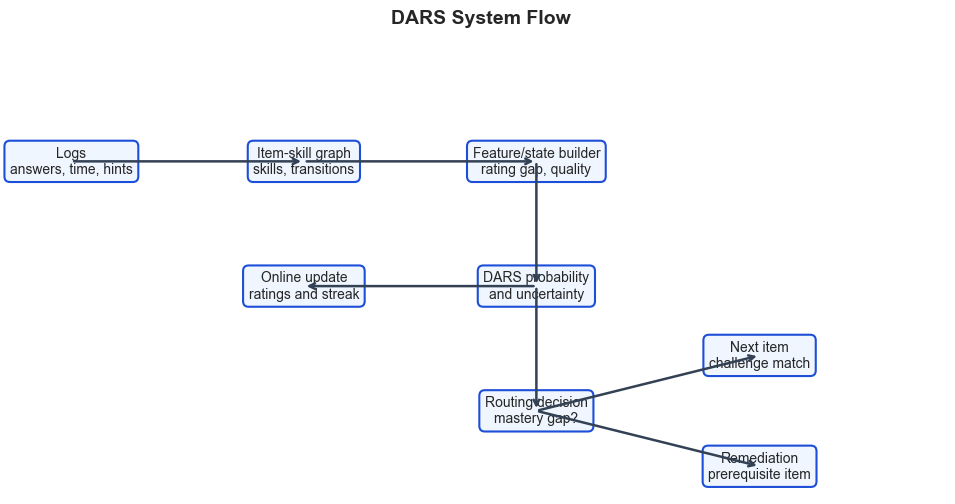

In [13]:
def draw_dars_system_flow():
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis("off")
    boxes = {
        "Logs\\nanswers, time, hints": (0.06, 0.72),
        "Item-skill graph\\nskills, transitions": (0.31, 0.72),
        "Feature/state builder\\nrating gap, quality": (0.56, 0.72),
        "DARS probability\\nand uncertainty": (0.56, 0.45),
        "Online update\\nratings and streak": (0.31, 0.45),
        "Routing decision\\nmastery gap?": (0.56, 0.18),
        "Next item\\nchallenge match": (0.80, 0.30),
        "Remediation\\nprerequisite item": (0.80, 0.06),
    }
    for text, (x0, y0) in boxes.items():
        ax.text(x0, y0, text.replace("\\n", "\n"), ha="center", va="center", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.4", fc="#eff6ff", ec="#1d4ed8", lw=1.5))
    arrows = [
        ("Logs\\nanswers, time, hints", "Item-skill graph\\nskills, transitions"),
        ("Item-skill graph\\nskills, transitions", "Feature/state builder\\nrating gap, quality"),
        ("Feature/state builder\\nrating gap, quality", "DARS probability\\nand uncertainty"),
        ("DARS probability\\nand uncertainty", "Online update\\nratings and streak"),
        ("DARS probability\\nand uncertainty", "Routing decision\\nmastery gap?"),
        ("Routing decision\\nmastery gap?", "Next item\\nchallenge match"),
        ("Routing decision\\nmastery gap?", "Remediation\\nprerequisite item"),
    ]
    for a, b in arrows:
        ax.annotate("", xy=boxes[b], xytext=boxes[a], arrowprops=dict(arrowstyle="->", lw=1.8, color="#334155"))
    ax.set_title("DARS System Flow", fontsize=14, fontweight="bold")
    fig.savefig(OUTPUT_DIR / "dars_enhanced_notebook_system_flow.png", dpi=300, bbox_inches="tight")
    plt.show()

draw_dars_system_flow()

## 9. Fairness and Cold-Start Analysis

In [14]:
fairness_df = pd.DataFrame({
    "Group": ["Easy", "Medium/Hard"],
    "N": [(y_test_np == 0).sum(), (y_test_np == 1).sum()],
    "Recall": [metrics["Specificity_TNR"], metrics["Sensitivity_TPR"]],
    "Error_Rate": [1 - metrics["Specificity_TNR"], 1 - metrics["Sensitivity_TPR"]],
})
recall_gap = abs(fairness_df.loc[0, "Recall"] - fairness_df.loc[1, "Recall"])
print(f"Recall parity gap: {recall_gap:.4f}")
display(fairness_df.style.format({"Recall": "{:.4f}", "Error_Rate": "{:.4f}"}))

test_acceptance = df.loc[X_test.index, "acceptance_rate_clean"].to_numpy()
quartiles = pd.qcut(test_acceptance, q=4, labels=["Q4 Low", "Q3", "Q2", "Q1 High"])

cold_rows = []
for q in ["Q1 High", "Q2", "Q3", "Q4 Low"]:
    mask = np.asarray(quartiles == q)
    q_y = y_test_np[mask]
    q_pred = y_pred[mask]
    q_prob = y_prob[mask]
    cold_rows.append({
        "Quartile": q,
        "Acceptance_Range": f"{test_acceptance[mask].min():.3f}-{test_acceptance[mask].max():.3f}",
        "N": int(mask.sum()),
        "Accuracy": accuracy_score(q_y, q_pred),
        "AUC": roc_auc_score(q_y, q_prob) if len(np.unique(q_y)) == 2 else np.nan,
        "ECE": expected_calibration_error(q_y, q_prob),
    })

cold_start_df = pd.DataFrame(cold_rows)
display(cold_start_df.style.format({"Accuracy": "{:.4f}", "AUC": "{:.4f}", "ECE": "{:.4f}"}))

Recall parity gap: 0.5606


,Group,N,Recall,Error_Rate
0,Easy,95,0.3579,0.6421
1,Medium/Hard,270,0.9185,0.0815


,Quartile,Acceptance_Range,N,Accuracy,AUC,ECE
0,Q1 High,0.622-0.943,91,0.6264,0.6637,0.1247
1,Q2,0.522-0.620,89,0.7416,0.8015,0.1036
2,Q3,0.425-0.521,93,0.7527,0.7754,0.1079
3,Q4 Low,0.139-0.422,92,0.9674,0.8665,0.0709


## 10. Executable DARS Online Update

This cell implements the algorithmic core described in the paper: expected correctness, response quality, dynamic update factor, rapid-guess penalty, and rating update.

In [15]:
def dars_expected_probability(learner_rating, item_rating, centrality=0.0, beta_c=40.0, local_skill_adjustment=0.0, beta_s=20.0):
    item_effective = item_rating + beta_c * centrality + beta_s * local_skill_adjustment
    return 1.0 / (1.0 + 10 ** ((item_effective - learner_rating) / 400.0))


def response_quality(correct, response_time, max_time=600, hints=0, max_hints=3, attempts=1, max_attempts=4, streak=0):
    tau = 1.0 - min(response_time / max_time, 1.0)
    hint_penalty = min(hints / max_hints, 1.0)
    attempt_penalty = min(max(attempts - 1, 0) / max_attempts, 1.0)
    streak_quality = 1.0 / (1.0 + math.exp(-streak / 3.0))
    if correct:
        return 0.35 * tau + 0.25 * (1 - hint_penalty) + 0.25 * (1 - attempt_penalty) + 0.15 * streak_quality
    return 0.05 * tau


def dynamic_k(n_attempts, uncertainty, k_min=8.0, k_max=40.0):
    experience_decay = 1.0 / math.sqrt(max(n_attempts, 1))
    uncertainty_boost = min(max(uncertainty, 0.0), 1.0)
    return k_min + (k_max - k_min) * max(experience_decay, uncertainty_boost)


def dars_update(state, item, observation):
    p = dars_expected_probability(
        state["rating"], item["rating"],
        centrality=item.get("centrality", 0.0),
        local_skill_adjustment=item.get("skill_adjustment", 0.0),
    )
    q = response_quality(
        observation["correct"], observation["response_time"],
        hints=observation.get("hints", 0), attempts=observation.get("attempts", 1),
        streak=state.get("streak", 0),
    )
    k = dynamic_k(state.get("attempts", 1), state.get("uncertainty", 0.5))
    streak_multiplier = 1.0 + min(abs(state.get("streak", 0)), 5) * 0.03
    rapid_guess_penalty = 6.0 if observation.get("response_time", 999) < item.get("min_time", 20) else 0.0
    delta = k * streak_multiplier * (q - p) - rapid_guess_penalty
    updated = dict(state)
    updated["rating"] = state["rating"] + delta
    updated["attempts"] = state.get("attempts", 0) + 1
    updated["streak"] = state.get("streak", 0) + (1 if observation["correct"] else -1)
    updated["uncertainty"] = max(0.05, state.get("uncertainty", 0.5) * 0.98)
    return updated, {"expected_probability": p, "quality": q, "k": k, "delta": delta}

learner_state = {"rating": 1500.0, "attempts": 12, "uncertainty": 0.35, "streak": 2}
item_state = {"rating": 1580.0, "centrality": 0.40, "skill_adjustment": 0.10, "min_time": 25}
observation = {"correct": True, "response_time": 180, "hints": 0, "attempts": 1}

updated_state, trace = dars_update(learner_state, item_state, observation)
print("Trace:", trace)
print("Before:", learner_state)
print("After:", updated_state)

Trace: {'expected_probability': 0.36259162325551547, 'quality': 0.8441134553148726, 'k': 19.2, 'delta': 9.799932326072035}
Before: {'rating': 1500.0, 'attempts': 12, 'uncertainty': 0.35, 'streak': 2}
After: {'rating': 1509.799932326072, 'attempts': 13, 'uncertainty': 0.34299999999999997, 'streak': 3}


## 11. Graph-Guided Remediation Routing

In [16]:
items = pd.DataFrame([
    {"item": "Arrays-1", "skill": "Array", "rating": 1250, "centrality": 0.20},
    {"item": "Arrays-2", "skill": "Array", "rating": 1400, "centrality": 0.35},
    {"item": "Sorting-1", "skill": "Sorting", "rating": 1500, "centrality": 0.45},
    {"item": "DP-Intro", "skill": "DP", "rating": 1550, "centrality": 0.50},
    {"item": "DP-Knapsack", "skill": "DP", "rating": 1750, "centrality": 0.75},
])

edges = {
    "DP-Knapsack": ["DP-Intro", "Sorting-1"],
    "DP-Intro": ["Arrays-2"],
    "Sorting-1": ["Arrays-2"],
    "Arrays-2": ["Arrays-1"],
}


def route_next_item(learner_rating, missed_item=None, remediation=False):
    candidates = items.copy()
    if remediation and missed_item in edges:
        candidates = candidates[candidates["item"].isin(edges[missed_item])].copy()
    target = learner_rating + (0 if remediation else 50)
    candidates["distance"] = (candidates["rating"] - target).abs()
    candidates["score"] = -candidates["distance"] + 25 * candidates["centrality"]
    return candidates.sort_values("score", ascending=False).iloc[0]

print("Challenge item:")
display(route_next_item(1500, remediation=False).to_frame().T)
print("Remediation after missing DP-Knapsack:")
display(route_next_item(1500, missed_item="DP-Knapsack", remediation=True).to_frame().T)

Challenge item:


,item,skill,rating,centrality,distance,score
3,DP-Intro,DP,1550,0.5,0,12.5


Remediation after missing DP-Knapsack:


,item,skill,rating,centrality,distance,score
2,Sorting-1,Sorting,1500,0.45,0,11.25


## 12. Export Notebook Results

In [17]:
summary_path = PROJECT_DIR / "DARS_Enhanced_Paper_Notebook_Results.csv"
summary = pd.DataFrame([{
    "Model": "DARS",
    "Accuracy": metrics["Accuracy"],
    "Sensitivity_TPR": metrics["Sensitivity_TPR"],
    "Specificity_TNR": metrics["Specificity_TNR"],
    "AUC": metrics["ROC_AUC"],
    "Brier": metrics["Brier"],
    "LogLoss": metrics["LogLoss"],
    "ECE": metrics["ECE"],
    "N_Train": len(X_train),
    "N_Test": len(X_test),
    "N_Features": X.shape[1],
    "Random_State": RANDOM_STATE,
}])
summary.to_csv(summary_path, index=False)
print(f"Saved {summary_path}")
display(summary)

Saved C:\Users\sunil\Downloads\btech-project\DARS_Enhanced_Paper_Notebook_Results.csv


,Model,Accuracy,Sensitivity_TPR,Specificity_TNR,AUC,Brier,LogLoss,ECE,N_Train,N_Test,N_Features,Random_State
0,DARS,0.772603,0.918519,0.357895,0.799454,0.155971,0.46908,0.04865,1460,365,11,2026
